In [238]:
# import stuff

import autograd.numpy as np 
import autograd
import matplotlib.pyplot as plt 
import math

# 1 a)

In [239]:
# Oppg 1 a

# Interpolation
def lagrange_interpolation_array(x_nodes, y_nodes, x_values):
    if len(x_nodes) != len(y_nodes):
        raise IndexError("Size of x_nodes and y_nodes should be the same")
    
    n = len(x_nodes) - 1

    def q_i(x, x_nodes, i):
        if i < 0 or i > n:
            raise IndexError("Indexen er utanfor node-talet")

        q = 1
        for nr in range(len(x_nodes)):
            if nr == int(i):
                continue
            q *= x - x_nodes[nr]
        return q

    y_values = []
    for x in x_values:

        y_values.append(sum([y_nodes[nr] * q_i(x, x_nodes, nr)/(q_i(x_nodes[nr], x_nodes, nr)) for nr in range(len(x_nodes))]))
    return y_values


def construct_p_n_function(x_nodes, y_nodes):
    return lambda x: lagrange_interpolation_array(x_nodes, y_nodes, x)


# Nodes:
def equidistant_nodes(node_count = 50):
    return np.linspace(-1, 1, node_count)

def chubychub_nodes(node_count = 50):
    count_nr = np.arange(0, node_count)
    return np.cos(((count_nr+1/2)*np.pi)/(node_count))

def rescale(nodes, start, end):
    return (end-start)/2 * nodes + (end+start)/2

In [240]:
# Pritty display




def display_interpolation(x_node_func, func, x_node_interval=(-1, 1), node_count=15, label=None, show_nodes=False):


    x_nodes = x_node_func(node_count)
    x_nodes = rescale(x_nodes, x_node_interval[0], x_node_interval[-1])
    y_nodes = func(x_nodes)

    x_vals = np.linspace(x_nodes[0], x_nodes[-1], 1000)
    y_interpolation_vals = lagrange_interpolation_array(x_nodes, y_nodes, x_vals)

    plt.plot(x_vals, y_interpolation_vals, label=label)
    plt.xlabel("x")
    plt.ylabel("p_n(x)")
    if show_nodes:
        plt.scatter(x_nodes, y_nodes, label=label)



def display_interpolation_error(x_node_func, func, x_node_interval=(-1, 1), node_count=15, label=None):

    x_nodes = x_node_func(node_count)
    x_nodes = rescale(x_nodes, x_node_interval[0], x_node_interval[1])
    y_nodes = func(x_nodes)

    x_vals = np.linspace(x_node_interval[0], x_node_interval[1], 1000)
    y_interpolation = lagrange_interpolation_array(x_nodes, y_nodes, x_vals)

    y_true = func(x_vals)

    error = np.abs(y_true - y_interpolation)

    plt.plot(x_vals, error, label=label)
    plt.xlabel("x")
    plt.ylabel("error: |f(x) - p_n(x)|")
    return np.max(error)



def finish_display():
    plt.legend()
    plt.tight_layout()
    plt.grid()
    plt.show()

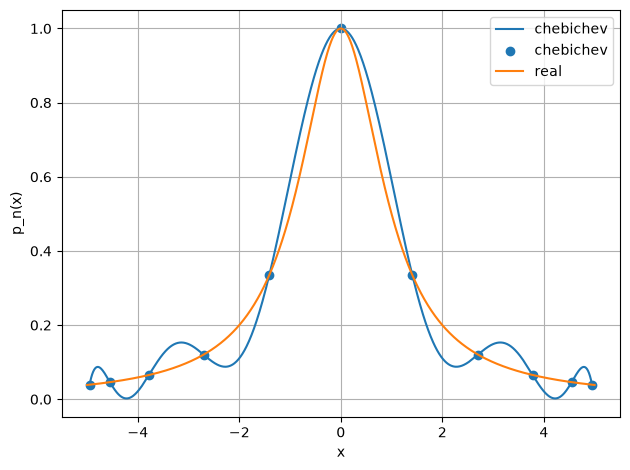

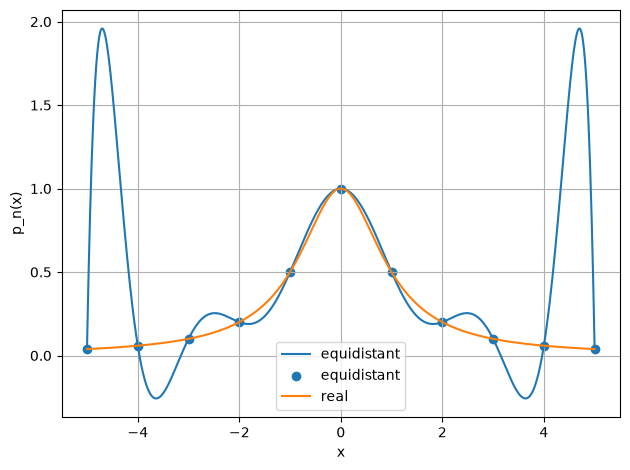

In [241]:

def runge_func(x_nodes):
    return 1/(x_nodes**2+1)



# plotting mr runge for 10 nodes
display_interpolation(chubychub_nodes, runge_func, (-5, 5), label="chebichev", node_count=11, show_nodes=True)
plt.plot(np.linspace(-5, 5, 1000), runge_func(np.linspace(-5, 5, 1000)), label="real")
finish_display()
display_interpolation(equidistant_nodes, runge_func, (-5, 5), label="equidistant", node_count=11, show_nodes=True)
plt.plot(np.linspace(-5, 5, 1000), runge_func(np.linspace(-5, 5, 1000)), label="real")
finish_display()



## Prediction time

For the same x span, but for  $n \in [15, 20, 30]$ i predict that the equidistant nodes wil fluctuate more towards the edges and doesnt converge, because for one thing it is apparent that it does above (with equidistant nodes) but also because in the lecture we found that a condition for uniform convergence is that $\lim\limits_{n \to \infty} \frac{M_{n+1}}{(n+1)!} \max\limits_{x \in [a, b]}|\Pi _{n+1}(x)| = 0$. Here $M_i$ is the upper bound of the $i$'th derivative of the function and $\Pi$ is the product of all $(x-x_i)$. For $f(x) = \frac{1}{1+x^2}$ this does not equal 0 for equidistant nodes, however it does for chebychev nodes. 

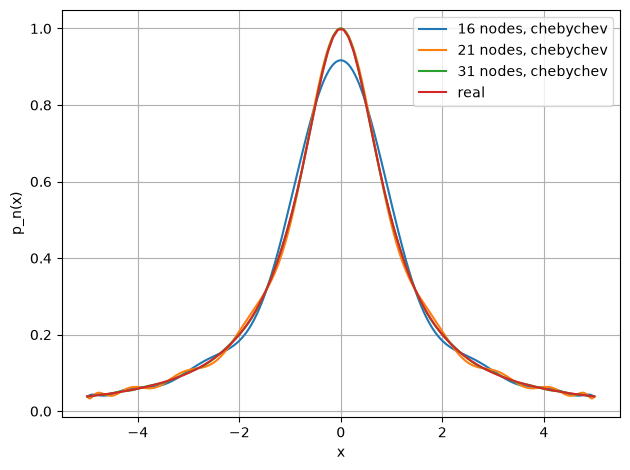

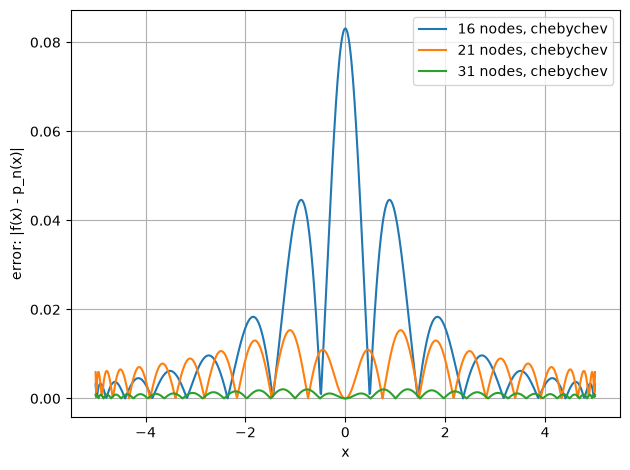

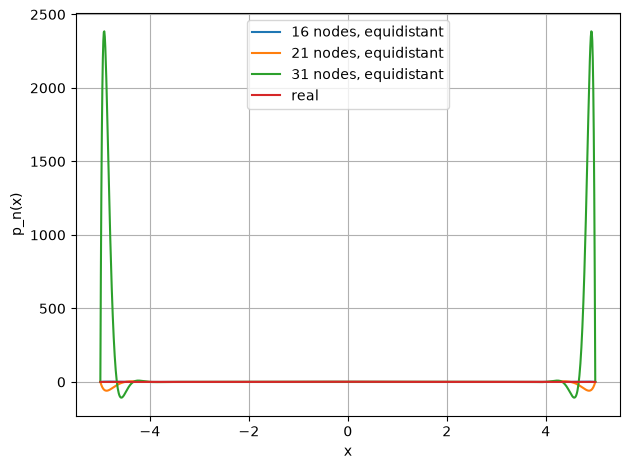

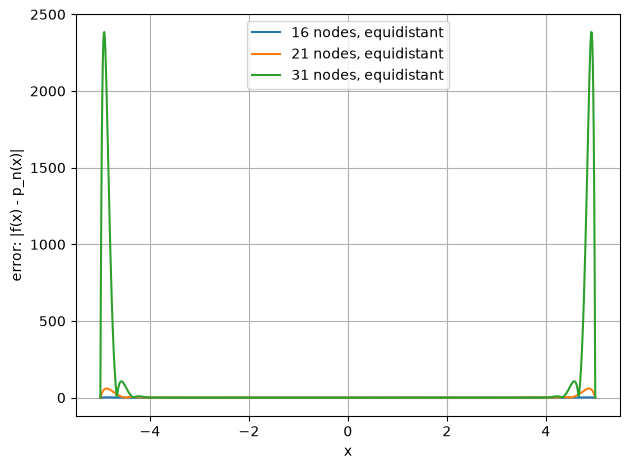

In [242]:
node_counts = np.array([16, 21, 31])

# Cheby
for node_count in node_counts:
    display_interpolation(chubychub_nodes, runge_func, (-5, 5), node_count=node_count, show_nodes=False, label=f"{node_count} nodes, chebychev")
plt.plot(np.linspace(-5, 5, 100), runge_func(np.linspace(-5, 5, 100)), label="real")
finish_display()


# Cheby error
for node_count in node_counts:
    display_interpolation_error(chubychub_nodes, runge_func, (-5, 5), node_count=node_count, label=f"{node_count} nodes, chebychev")
finish_display()



# equi
for node_count in node_counts:
    display_interpolation(equidistant_nodes, runge_func, (-5, 5), node_count=node_count, show_nodes=False, label=f"{node_count} nodes, equidistant")
plt.plot(np.linspace(-5, 5, 100), runge_func(np.linspace(-5, 5, 100)), label="real")
finish_display()


# Equi error
for node_count in node_counts:
    display_interpolation_error(equidistant_nodes, runge_func, (-5, 5), node_count=node_count, label=f"{node_count} nodes, equidistant")
finish_display()



### Outcome vs prediction

You can see that there was much more occilation in the equidistant nodes as supposed to chebychev nodes. When we look at the error we see that for chebychev nodes, the error decrese for biger node count and it's somewhat evenly spaced however for the equidistant nodes, the error is bigger the more nodes there are, and it is biggest at the edges, where it occilates most.

### Predcition for $x \in [-1, 1]$

Considering this looks ore like a polynomial function i am guessing the error wil be smaller, but as chebychev nodes has the optimal node separation for separation, i am guessing that will stil have a smaller error. I am also guessing that the error wil be about equaly distributed along x in chebychev nodes, while being bigger at the edges for the equidistant ones. I am also guessing the overall error will become bigger the more nodes there are for equidistant nodes and smaller for chebichev nodes, reason being that the error diverges for equidistant nodes and converges to 0 for chebichev, and that is the trend from before. 

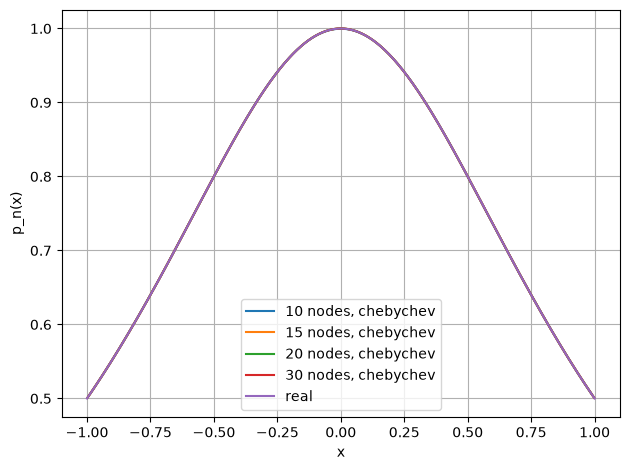

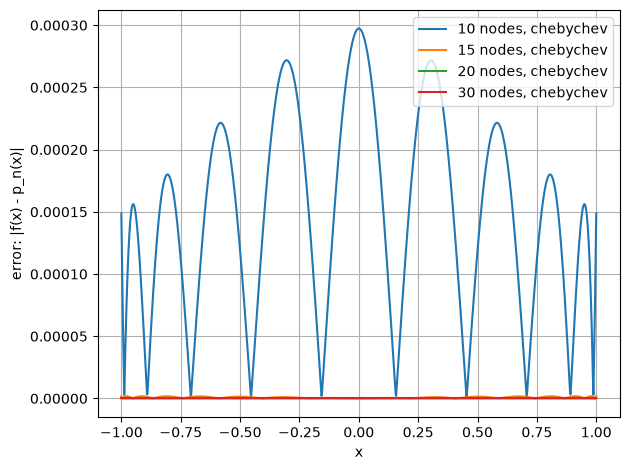

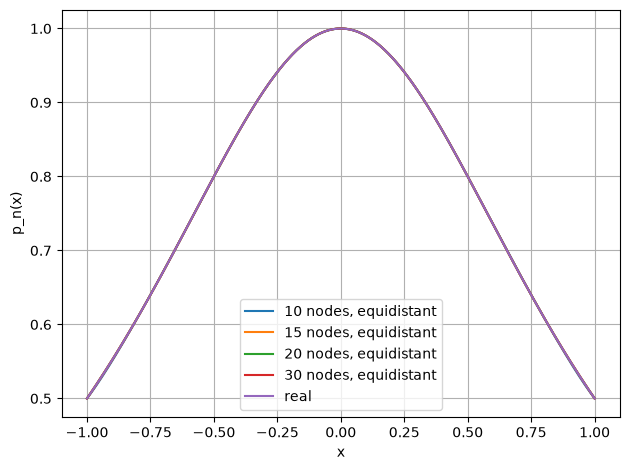

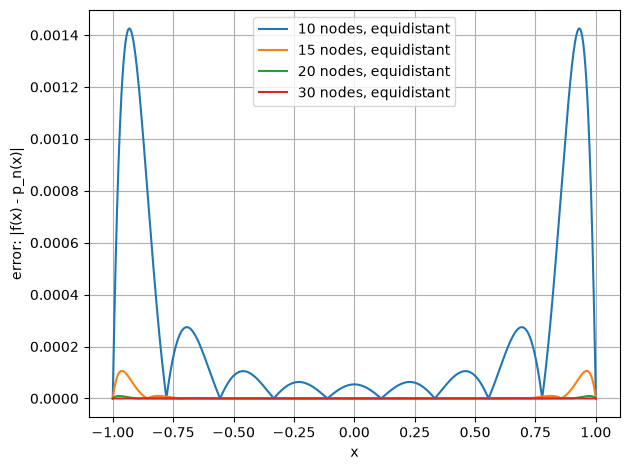

In [243]:
# Now for the interval [-1, 1]


# Cheby
for node_count in [10, 15, 20, 30]:
    display_interpolation(chubychub_nodes, runge_func, (-1, 1), node_count=node_count, show_nodes=False, label=f"{node_count} nodes, chebychev")
plt.plot(np.linspace(-1, 1, 100), runge_func(np.linspace(-1, 1, 100)), label="real")
finish_display()


# Cheby error
for node_count in [10, 15, 20, 30]:
    display_interpolation_error(chubychub_nodes, runge_func, (-1, 1), node_count=node_count, label=f"{node_count} nodes, chebychev")
finish_display()



# equi
for node_count in [10, 15, 20, 30]:
    display_interpolation(equidistant_nodes, runge_func, (-1, 1), node_count=node_count, show_nodes=False, label=f"{node_count} nodes, equidistant")
plt.plot(np.linspace(-1, 1, 100), runge_func(np.linspace(-1, 1, 100)), label="real")
finish_display()


# Equi error
for node_count in [10, 15, 20, 30]:
    display_interpolation_error(equidistant_nodes, runge_func, (-1, 1), node_count=node_count, label=f"{node_count} nodes, equidistant")
finish_display()

## Comment of error

The error is now much smaller as expected. For chebichev nodes the error is biger towards the center something i had not predicted, but the equdistant error is indeed bigger towards the edges. For some reason, the error for equidistant nodes doesn't diverge the more nodes i have for that interval, which is against my prediction.

# 1 b)

Why does both two- and max-norm converge for the functions $f_1(x) = \cos(2\pi x)$ and $f_2(x) = e^{3x}\sin(2x)$, for both chebychev and equidistant nodes, as the nodecount increses? If we find that the interpolation converge, with this condition (mentioned earlier) $\lim\limits_{n \to \infty} \frac{M_{n+1}}{(n+1)!} \max\limits_{x \in [a, b]}|\Pi _{n+1}(x)| = 0$, we know that the two- and max-norm will also converge towards the norm of the function over which we interpolate. That is because this condition is an upper bound of the max-norm of the error between the function and its interpolation polynomial. We know from the ML inequality that $$\|f-p_n\|_2^2 = \int_a^b |f(x)-p_n(x)|^2 dx \leq (b-a)\|f-p_n\|_\infty^2.$$ Taking the square root on both sides gives $$\boxed{\|f-p_n\|_2 \leq \sqrt{b-a}\|f-p_n\|_\infty}$$ so if the max-norm of the error goes to zero, the $2$-norm of the error also goes to zero on the fixed interval $[a,b]$.

Mathematicaly we can say: $$\lim\limits_{n \to \infty}\frac{M_{n+1}}{(n+1)!}\max\limits_{x\in[a,b]}|\Pi_{n+1}(x)| = 0 \implies \|f-p_n\|_\infty \to 0 \implies$$ $$\|f-p_n\|_2 \to 0 \implies \|p_n\|_\infty \to \|f\|_\infty,\ \|p_n\|_2 \to \|f\|_2$$

First, differentiating over $f_1(x)$ we get that $\max(|f_1^{(n+1)}(x)|) = (2 \pi)^{n+1}$
$$f_1^{(n+1)}(x) = (2\pi)^{n+1}\cos\left(2\pi x+\frac{(n+1)\pi}{2}\right)$$
$$\max_{x\in[0,1]}|f_1^{(n+1)}(x)| = (2\pi)^{n+1}\cdot 1 = (2\pi)^{n+1}$$
$$\boxed{M_{n+1} = (2 \pi)^{n+1}}$$

is an upper bound for $f_1^{(n+1)}(x)$. Differentiating over $f_2(x)$ gives $$f_2^{(n+1)}(x) = \frac{d^{n+1}}{dx^{n+1}} (Im(e^{(3+2i)x})) = Im(\frac{d^{n+1}}{dx^{n+1}}(e^{(3+2i)x})) = Im((3+2i)^{n+1}e^{(3+2i)x})$$, so $|f_2^{(n+1)}(x)| \leq |(3+2i)^{n+1}e^{(3+2i)x}| \leq (\sqrt{3^2 + 2^2})^{n+1}e^{3x} = 13^{\frac{n+1}{2}}e^{3x}$. Considering $x \in [0, \frac{\pi}{4}]$, we can set $\boxed{M_{n+1} = 13^{\frac{n+1}{2}}e^{\frac{3 \pi}{4}}}$ as an upper bound for $f_2^{(n+1)}(x)$.

For this part, $\max\limits_{x \in [a, b]}|\Pi _{n+1}(x)|$, we know that the biggest interval we are looking at is $x \in [0, 1]$ for $f_1$ and $x \in [0, \frac{\pi}{4}]$ for $f_2$, so $|x-x_i| \leq |1-0| = 1$ for both functions. For all the nodes we get $\boxed{\max\limits_{x \in [a, b]}|\Pi _{n+1}(x)| \leq 1^{n+1} = 1}$. For a tighter upper bound for $f_2(x)$ we can similarly derive $\boxed{\max\limits_{x \in [a, b]}|\Pi _{n+1}(x)| \leq (\frac{\pi}{4})^{n+1}}$

Combining this we get $\lim\limits_{n \to \infty} \frac{M_{n+1}}{(n+1)!} \max\limits_{x \in [0, 1]}|\Pi _{n+1}(x)| \leq \lim\limits_{n \to \infty} \frac{(2 \pi)^{n+1}}{(n+1)!}$ for $f_1(x)$ and $\lim\limits_{n \to \infty} \frac{M_{n+1}}{(n+1)!} \max\limits_{x \in [0, \frac{\pi}{4}]}|\Pi _{n+1}(x)| \leq \lim\limits_{n \to \infty} \frac{13^{\frac{n+1}{2}}e^{\frac{3 \pi}{4}} (\frac{\pi}{4})^{n+1}}{(n+1)!}$ for $f_2(x)$. We know that as $n \to \infty$, factorials grow faster than exponentials, so both goes to 0. $\boxed{\lim\limits_{n\to\infty}\|f-p_n\|_\infty = \lim\limits_{n \to \infty}\|f-p_n\|_2 = 0}$ 

In [244]:
def norm_max(f, x_values):
    return np.max(np.abs(f(x_values)))

def norm_2(f, x_values):
    return np.sqrt(x_values[-1]-x_values[0])/np.sqrt(len(x_values)) * np.sqrt(np.sum(f(x_values)**2))


def norm_max_from_array(y_values):
    return np.max(np.abs(y_values))


def norm_2_from_arrays(y_values, x_values):
    return np.sqrt((x_values[-1] - x_values[0]) / len(x_values)) * np.sqrt(np.sum(np.abs(y_values)**2))



def interpolation_error_norm(f, p_n, norm, x_values):
    diff = lambda x: f(x) - p_n(x)
    return norm(diff, x_values)





def error_norm_from_nodes(f, x_nodes, norm, x_count):

    p_n = construct_p_n_function(x_nodes, f(x_nodes))

    x_values = np.linspace(np.min(x_nodes), np.max(x_nodes), x_count)


    return interpolation_error_norm(f, p_n, norm, x_values)

def upper_bound_analy_error_f_1(n):
    return (2*np.pi)**(n+1)/(math.factorial(n+1))
def upper_bound_analy_error_f_2(n):
    return 13**((n+1)/2) * np.exp(3*np.pi/4) * (np.pi/4)**(n+1)/(math.factorial(n+1))


def diaplay_analy_upper_error(bounded_func, node_counts, label=None, log_scale=False):
    error = np.array([bounded_func(int(n)) for n in node_counts])
    if log_scale:
        error = np.log10(error)
    plt.plot(node_counts, error, label=label)



def display_error_norms(f, x_interval, node_type, norm, node_counts, label=None, log_scale=False):
    error_norms = []
    for n in node_counts:
        x_nodes = rescale(node_type(n), x_interval[0], x_interval[-1])

        e_norm = error_norm_from_nodes(f, x_nodes, norm, 1000)
        error_norms.append(e_norm)
    if log_scale:
        error_norms = np.log10(np.array(error_norms))
        plt.ylabel("error norm, $log(||f(x) - p_n(x)||)$")
    else:
        plt.ylabel("error norm, $||f(x) - p_n(x)||$")

    plt.plot(node_counts, error_norms, label=label)
    plt.xlabel("node count")

    


In [245]:
#function_defenitions

def f_1_b(x):
    return np.cos(2*np.pi * x)

def f_2_b(x):
    return np.exp(3*x) * np.sin(2*x)



/home/thomas/Documents/school/Skule_ting/.venv/lib/python3.14/site-packages/autograd/tracer.py:93: RuntimeWarning: divide by zero encountered in log10
  return f_raw(*args, **kwargs)


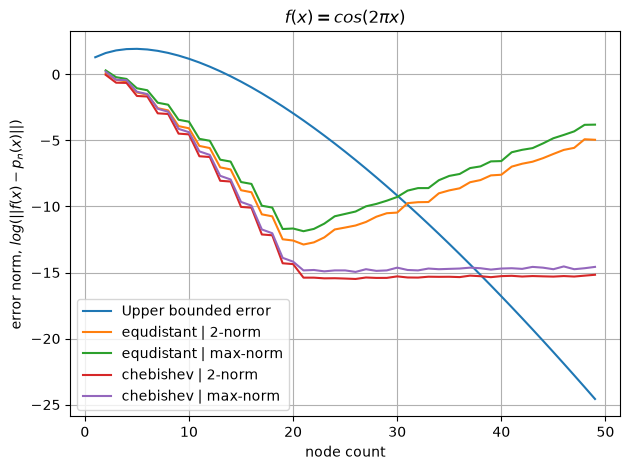

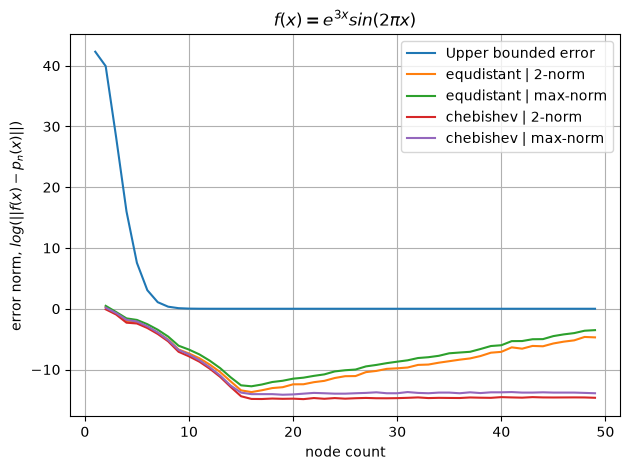

In [246]:
# display:

node_counts = np.arange(1, 50)
plt.title(r"$f(x) = cos(2 \pi x)$")
diaplay_analy_upper_error(upper_bound_analy_error_f_1, node_counts, label="Upper bounded error", log_scale=True)
display_error_norms(f_1_b, (0, 1), equidistant_nodes, norm_2, node_counts, label="equdistant | 2-norm", log_scale=True)
display_error_norms(f_1_b, (0, 1), equidistant_nodes, norm_max, node_counts, label="equdistant | max-norm", log_scale=True)
display_error_norms(f_1_b, (0, 1), chubychub_nodes, norm_2, node_counts, label="chebishev | 2-norm", log_scale=True)
display_error_norms(f_1_b, (0, 1), chubychub_nodes, norm_max, node_counts, label="chebishev | max-norm", log_scale=True)
finish_display()

plt.title(r"$f(x) = e^{3x}sin(2 \pi x)$")
diaplay_analy_upper_error(upper_bound_analy_error_f_2, node_counts, label="Upper bounded error")
display_error_norms(f_2_b, (0, np.pi/4), equidistant_nodes, norm_2, node_counts, label="equdistant | 2-norm", log_scale=True)
display_error_norms(f_2_b, (0, np.pi/4), equidistant_nodes, norm_max, node_counts, label="equdistant | max-norm", log_scale=True)
display_error_norms(f_2_b, (0, np.pi/4), chubychub_nodes, norm_2, node_counts, label="chebishev | 2-norm", log_scale=True)
display_error_norms(f_2_b, (0, np.pi/4), chubychub_nodes, norm_max, node_counts, label="chebishev | max-norm", log_scale=True)
finish_display()


### Upper bound vs numerical norm

One can see that the upper bound is quite a lot bigger than the numerical error norm we found. When considering the culprits there are 2 terms that maters most.Those are $M_{n+1}$ and $\max\limits_{x \in [a, b]}|\Pi _{n+1}(x)|$. There are no approximation computing the factorial term, so this term doesn't make it bigger than necesary. 

When approximating $\max\limits_{x \in [a, b]}|\Pi _{n+1}(x)|$ we used that the distance between the nodes can not exceed the length of the entire interval, and so we assumed all the x values to have the distance $|x_{max} - x_{min}|$ from the nodes. For any real node placements this distance would definately be smaller. For example, for chebyshev nodes this term would be $\max |\Pi_{n+1}| \leq \frac{1}{2^n}$ for $x \in [-1, 1]$, instead of $(1-(-1))^{n+1} = 2^{n+1}$ which our approach would have choosen.

When choosing $M_{n+1}$ however, for $f_1$, we chose the exact maximal derivative of the function at that interval, so this term does find the global upper bound. Nevertheless this could be smaller as the actual value apparing in the interpolation error ($f^{n+1}(\xi_x)$) could indeed be smaller.

Thus i think the main gap between the upper bound and the numerical error norm is from the approximation of the nodal polynomial term but both does contribute.



TOMAYBEDO: roundof error max (lagrange polynom)??? Equi distant feil propagerer

TODO: Sjå på spesifike verdier error feilen

# 1 c)

In [247]:
def sub_interval_interpolation(func, start, end, interval_count, subinterval_node_count, x_val_count=1000):
    intervals = np.linspace(start, end, interval_count+1)

    x_vals_tot = []
    y_interpol_tot = []
    for i in range(len(intervals)-1):
        x_nodes = rescale(equidistant_nodes(subinterval_node_count), intervals[i], intervals[i+1])
        y_nodes = func(x_nodes)

        # If we increase the intervals, we only evaluate each interval on fewer x values
        x_vals = np.linspace(np.min(x_nodes), np.max(x_nodes), int(x_val_count/interval_count)) 
        y_interpolation = lagrange_interpolation_array(x_nodes, y_nodes, x_vals)

        x_vals_tot.append(x_vals)
        y_interpol_tot.append(y_interpolation)

    x_vals_tot = np.concatenate(x_vals_tot)
    y_interpol_tot = np.concatenate(y_interpol_tot)

    return x_vals_tot, y_interpol_tot





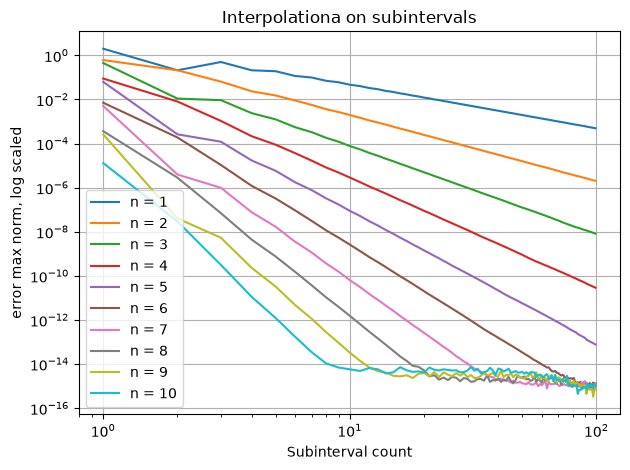

In [248]:
x = np.linspace(0, 1, 1000)

node_counts = np.arange(1, 11)+1 # Nodecount = n + 1
disjoint_interval_counts = np.arange(1, 100)
for node_count in node_counts:

    plt.title(f"Interpolationa on subintervals")
    max_norm_errors = []
    for K in disjoint_interval_counts:
        x, y = sub_interval_interpolation(f_1_b, np.min(x), np.max(x), K, node_count)
        max_norm_errors.append(norm_max_from_array(np.abs(y-f_1_b(x))))

    plt.loglog(disjoint_interval_counts, max_norm_errors, label=f"n = {node_count-1}")
    plt.xlabel("Subinterval count")
    plt.ylabel("error max norm, log scaled")

finish_display()

## Comparing interpolation method

A big advantage of subdividing the interpolation area is that we get less occilation toward the ends of the intervals as we have smaller of an interval to fitt, and thus it is more likely to have a a more linear nature?

# ...


Dele opp i grafar med forksjellige n og vise global error vs piecewise 

Samanliknar tida det tar å å køyre kvar av dei for antal n fleire gangar og tek avg

In [249]:
def interpolation_runtime_comparason(f, x, sub_node_count, K_values, repeats=3):
    start, end = np.min(x), np.max(x)
    real_f = f(x)
    total_nodes = K_values * (sub_node_count - 1) + 1
    
    global_cheby_times = np.zeros(len(K_values))
    global_equi_times = np.zeros(len(K_values))
    sub_times = np.zeros(len(K_values))

    cheby_errors = np.zeros(len(K_values))
    equi_errors = np.zeros(len(K_values))
    sub_errors = np.zeros(len(K_values))

    for k_idx, k in enumerate(K_values):
        node_count = total_nodes[k_idx]
        global_cheby_times_temp = np.zeros(repeats)
        global_equi_times_temp = np.zeros(repeats)
        sub_times_temp = np.zeros(repeats)

        for i in range(repeats):
            start_time = time.perf_counter()
            x_sub, y_sub = sub_interval_interpolation(f, start, end, k, sub_node_count, len(x))
            sub_times_temp[i] = time.perf_counter() - start_time

            start_time = time.perf_counter()
            cheby_nodes = rescale(chubychub_nodes(node_count), start, end)
            y_cheby = lagrange_interpolation_array(cheby_nodes, f(cheby_nodes), x)
            global_cheby_times_temp[i] = time.perf_counter() - start_time

            start_time = time.perf_counter()
            equi_nodes = rescale(equidistant_nodes(node_count), start, end)
            y_equi = lagrange_interpolation_array(equi_nodes, f(equi_nodes), x)
            global_equi_times_temp[i] = time.perf_counter() - start_time

        global_cheby_times[k_idx] = np.mean(global_cheby_times_temp)
        global_equi_times[k_idx] = np.mean(global_equi_times_temp)
        sub_times[k_idx] = np.mean(sub_times_temp)

        cheby_errors[k_idx] = norm_max_from_array(real_f - y_cheby)
        equi_errors[k_idx] = norm_max_from_array(real_f - y_equi)
        sub_errors[k_idx] = norm_max_from_array(f(x_sub) - y_sub)

    return (total_nodes, global_equi_times, global_cheby_times, sub_times, equi_errors, cheby_errors, sub_errors)






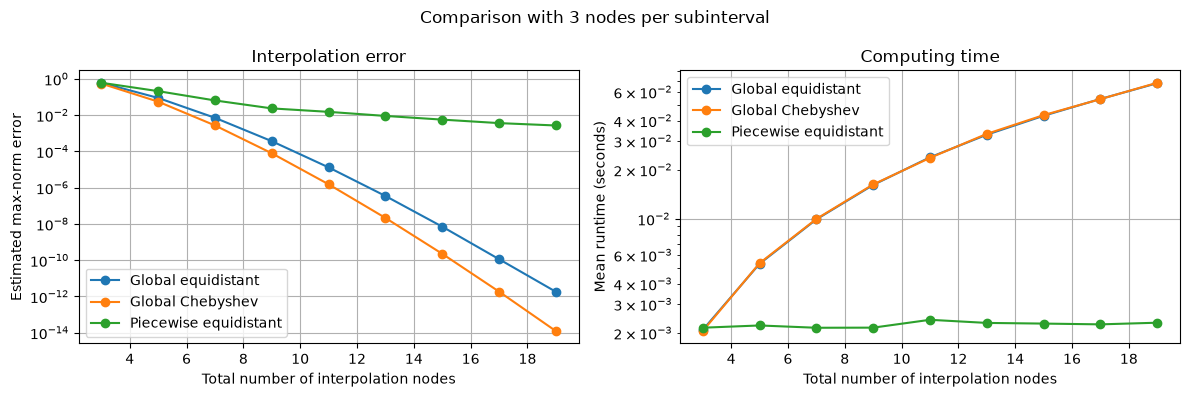

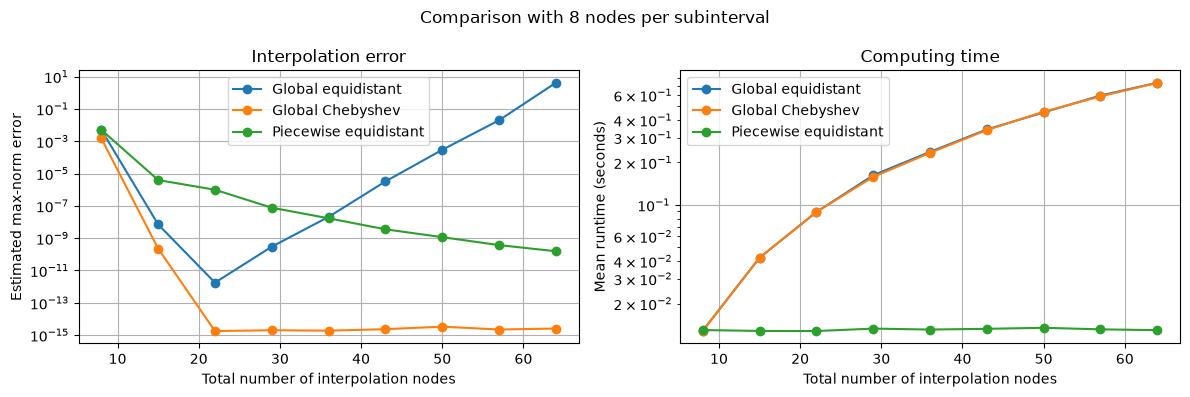

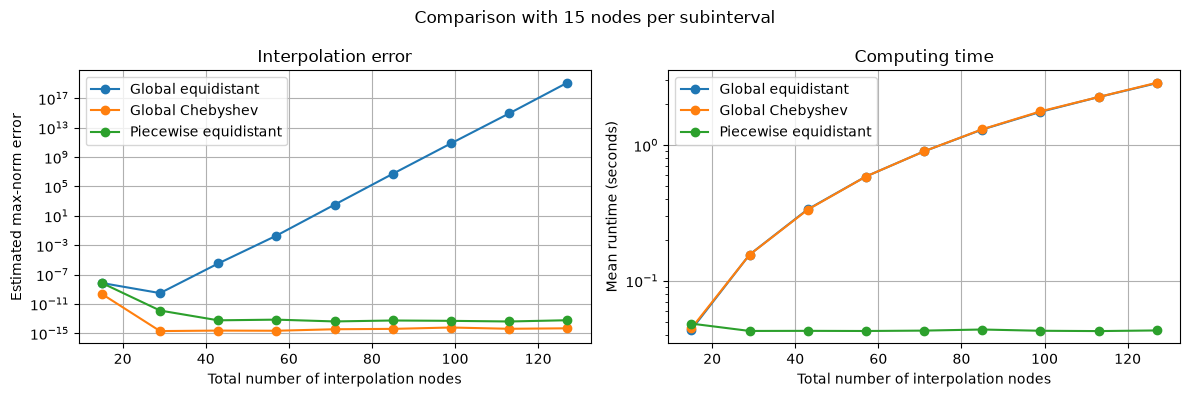

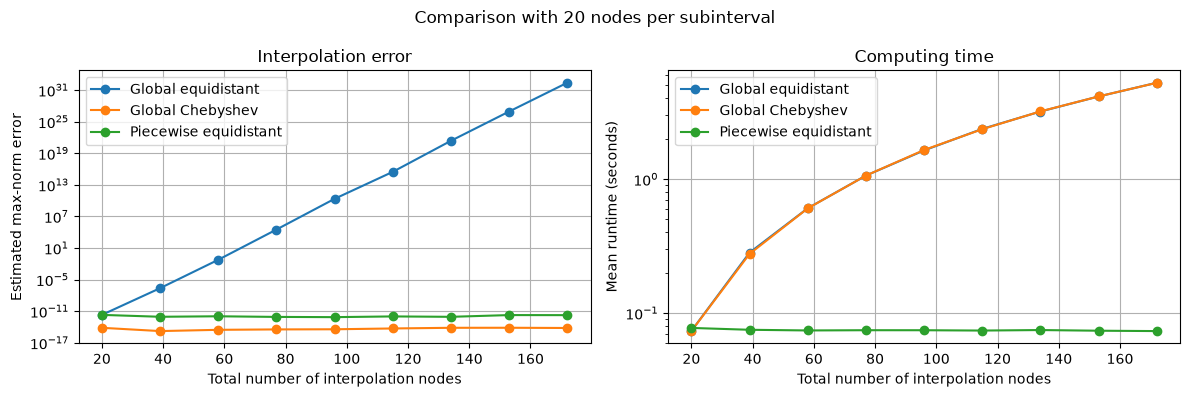

In [ ]:
def plot_interpolation_comparison(results, sub_node_count):
    (nodes, equi_times, cheby_times, sub_times, equi_errors, cheby_errors, sub_errors) = results

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Comparison with {sub_node_count} nodes per subinterval")

    axes[0].semilogy(nodes, equi_errors, "o-", label="Global equidistant")
    axes[0].semilogy(nodes, cheby_errors, "o-", label="Global Chebyshev")
    axes[0].semilogy(nodes, sub_errors, "o-", label="Piecewise equidistant")
    axes[0].set_title("Interpolation error")
    axes[0].set_ylabel("Estimated max-norm error")

    axes[1].semilogy(nodes, equi_times, "o-", label="Global equidistant")
    axes[1].semilogy(nodes, cheby_times, "o-", label="Global Chebyshev")
    axes[1].semilogy(nodes, sub_times, "o-", label="Piecewise equidistant")
    axes[1].set_title("Computing time")
    axes[1].set_ylabel("Mean runtime (seconds)")

    for ax in axes:
        ax.set_xlabel("Total number of interpolation nodes")
        ax.grid()
        ax.legend()

    fig.tight_layout()
    plt.show()




x = np.linspace(0, 1, 1001)
K_values = np.arange(1, 10)
sub_node_counts = np.array([3]) # [3, 8, 15, 20]
for sub_node_count in sub_node_counts:
    results = interpolation_runtime_comparason(f_1_b, x, sub_node_count=sub_node_count, K_values=K_values, repeats=3)

    plot_interpolation_comparison(results, sub_node_count)


## Comparason conclusion
All the graphs represent the error and how long it tok to do the interpolation with the differente interpolationmethods. Each graph represents a set node count per subinterval, and as we let K go from 1 to 9 we increase the total node count making it equal for all the methods and thus a fair test.

From the result, we can see that the computation time is just about eqal for the differente global interpolations, meaning the node placement doesn't effect the computation time. Its resulting error however is allways smaller for chebyshev nodes, meaning one should clarely choose the chebichev between those two.

The time it takes to interpolate piecewise seems to be basicaly constant, and always smaller than the other two. That is because the number of nodes per subinterval is fixed, while the total number of evaluation points stays approximately constant. Increasing $K$ gives more subintervals but fewer evaluation points in each, so the total interpolation work remains roughly unchanged. For global interpolation, each evaluation uses all the interpolation nodes, so increasing the total node count increases the computational cost.

The chebichev nodes always give a smaller interpolation error, however for many nodes per interval, this difference may be small enough for the bennefit of a small computation cost to dominate, depending on the situation.

# 1 d)

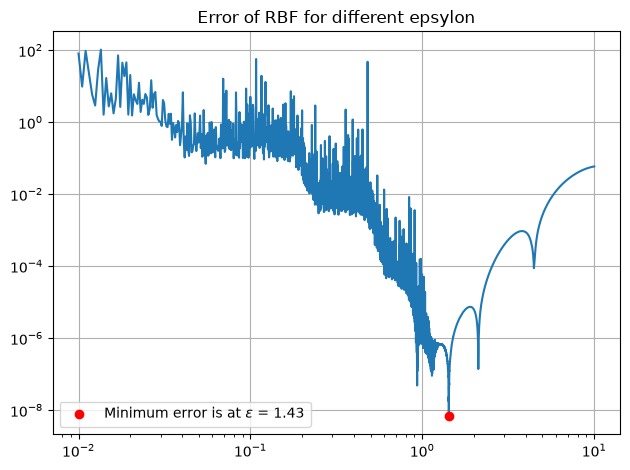

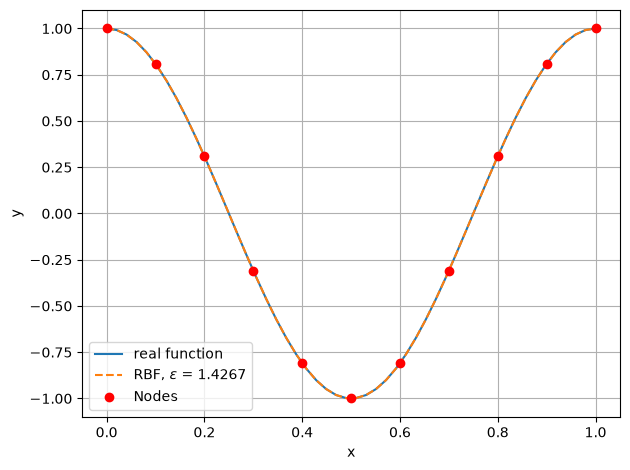

In [251]:



def theta(r, epsylon):
    return np.exp(-(epsylon * r)**2)

def compute_M(x_nodes, epsylon):
    # Vi treng bare å konstruere sub diagonalen da diagonalen er 1 theta(x_i-x_i) = 1 
    # og den er symetrisk theta(x_i-x_j) = theta(x_j-x_i)
    n = len(x_nodes)
    rows = []

    for i in range(n):
        row = []
        for j in range(n):
            if j < i:
                row.append(theta(x_nodes[i] - x_nodes[j], epsylon))
            else:
                row.append(0.0)
        rows.append(row)

    M = np.array(rows)
    return M + M.T + np.identity(n)


def RBF(x_nodes, y_nodes, x, epsylon):
    # diagonals = 1
    n = len(x_nodes)
    M = compute_M(x_nodes, epsylon)

    weights = np.linalg.solve(M, y_nodes)
    return np.sum([w_i * theta(x-x_nodes[nr], epsylon=epsylon) for nr, w_i in enumerate(weights)], axis=0)


def plot_error_of_RBF(epsylons, x, norm_from_array, f, node_count=11):
    errors = np.zeros_like(epsylons)

    for nr, epsylon in enumerate(epsylons):
        x_nodes = rescale(equidistant_nodes(node_count=node_count), np.min(x), np.max(x))
        y_nodes = f(x_nodes)
        

        try:
            f_hat = RBF(x_nodes, y_nodes, x, epsylon=epsylon)
            errors[nr] = norm_from_array(f_hat - f(x))
        except np.linalg.LinAlgError:
            errors[nr] = np.inf


    plt.title("Error of RBF for different epsylon")
    plt.loglog(epsylons, errors)
    return errors



def idx_x_y_from_min_y(x, y):
    min_idx = np.argmin(errors)
    return min_idx, x[min_idx], y[min_idx]


x_vals = np.linspace(0, 1)
f = f_1_b

epsylons = np.linspace(0.01, 10, 20000)
errors = plot_error_of_RBF(epsylons, x_vals, norm_max_from_array, f)
min_idx, best_epsylon, _ = idx_x_y_from_min_y(epsylons, errors)
plt.scatter(best_epsylon, errors[min_idx], color="red", label=rf"Minimum error is at $\epsilon$ = {epsylons[min_idx]:.2f}", zorder=3)
finish_display()


# Show how good we get


def test_our_new_epsylon_on_RBF(epsylon, f, x_vals, node_count=11):
    x_nodes = rescale(equidistant_nodes(node_count=node_count), np.min(x_vals), np.max(x_vals))
    y_nodes = f(x_nodes)

    f_hat = RBF(x_nodes, y_nodes, x_vals, epsylon=epsylon)
    plt.plot(x_vals, f(x_vals), label="real function")
    plt.plot(x_vals, f_hat, "--", label=rf"RBF, $\epsilon$ = {epsylon:.4f}")
    plt.scatter(x_nodes, y_nodes, color="red", label="Nodes", zorder=3)
    plt.xlabel("x")
    plt.ylabel("y")
    finish_display()


test_our_new_epsylon_on_RBF(best_epsylon, f, x_vals)






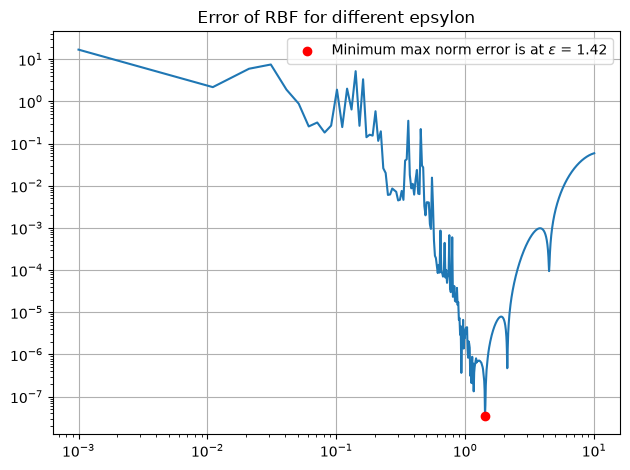

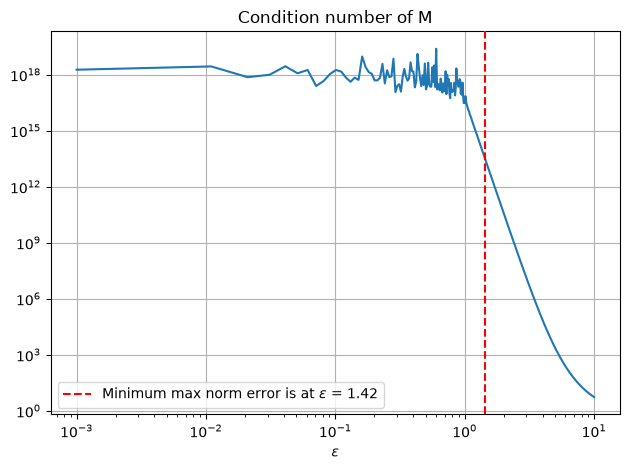

In [252]:
# Condition number

def condition_M(x_nodes, f, epsylons):
    conds = np.zeros_like(epsylons)
    for nr, epsilon in enumerate(epsylons):
        M = compute_M(x_nodes, epsilon)
        conds[nr] = np.linalg.cond(M)

    return conds

def display_condition(epsilons, x, f, node_count=11):
    x_nodes = rescale(equidistant_nodes(node_count), np.min(x), np.max(x))

    conds = condition_M(x_nodes, f, epsilons)

    plt.title("Condition number of M")
    
    plt.loglog(epsilons, conds)
    plt.xlabel(r"$\epsilon$")

    


epsylons = np.linspace(0.001, 10, 1000)
x_vals = np.linspace(0, 1, 1000)
f = f_1_b

errors = plot_error_of_RBF(epsylons, x_vals, norm_max_from_array, f)
min_idx, best_epsylon, _ = idx_x_y_from_min_y(epsylons, errors)
plt.scatter(best_epsylon, errors[min_idx], color="red", label=rf"Minimum max norm error is at $\epsilon$ = {epsylons[min_idx]:.2f}", zorder=3)
finish_display()
display_condition(epsylons, x_vals, f)
plt.axvline(best_epsylon, color="red", linestyle="--", label=rf"Minimum max norm error is at $\epsilon$ = {best_epsylon:.2f}", zorder=3)
finish_display()



## Condition number vs max norm error tredeoff

We can see that at the epsylon giving the minimum max norm error for RBF also gives quite a large condition number (around $10^{13}$). The conditionnumber is defined as $$\kappa(M) = \|M\| \cdot \|M^{-1}\|$$ comming from the expression $$\frac{\|\Delta x\|}{\|x\|}\leq\kappa(M)\frac{\|\Delta b\|}{\|b\|},$$ where $\Delta b$ is an error in the right-hand side of $Mx=b$, and $\Delta x$ is the resulting error in the solution, with $M$ unchanged. Thus, $\kappa(M)=\|M\|\|M^{-1}\|$ bounds how much the relative error in $b$ can be amplified in $x$. 

Considering we have a large condition number we can not be very certain of the resulting x as a small error in $b$ makes  $\frac{\|\Delta x\|}{\|x\|}\leq 10^{13} \frac{\|\Delta b\|}{\|b\|}$. Choosing a slightly bigger $\epsilon$ for less amplification in the error of x could thus be beneficial for an accurate result.

The reason i think the condition number is so bigg for small $\epsilon$ is that for small $\epsilon$, each entry $$M_{ij}=e^{-\epsilon^2(x_i-x_j)^2}\to 1 \quad \text{as }\epsilon\to 0.$$ Thus, $M$ approaches the matrix of only ones, which is singular. For the 2-norm we get
$$\|M^{-1}\|_2 = \frac{1}{\lambda_{\min}(M)} \to \infty \quad \text{as } \epsilon \to 0.$$

Here $\lambda_{\min}(M)$ is the smallest eigenvalue of $M$. As it approaches zero, rounding errors can become large relative to this eigenvalue. Consequently, the computed condition number itself becomes less accurate for very small $\epsilon$, which can explain the fluctuations and plateau in the plot.

# 1 e)

In [262]:
def cost_func(x, epsilon, f, x_nodes):
    start_x = np.min(x)
    end_x = np.max(x)
    N = len(x) - 1


    RBF_array = RBF(x_nodes, f(x_nodes), x, epsilon)


    return (end_x - start_x)/N * np.sum((f(x)-RBF_array)**2)



def grad_cost(f, x):
    # params = [x_nodes, epsilon] this is what we want to differentiate with respect to
    cost = lambda params: cost_func(x, params[-1], f, params[:-1])
    return autograd.grad(cost)



def gradient_decent(x, f, initial_params, initial_L, p_hat, p_sub_hat):
    cost_f = lambda params: cost_func(x, params[-1], f, params[:-1])
    grad = grad_cost(f, x)

    params = initial_params
    L = initial_L

    cost = cost_f(params)

    for _ in range(100):
        g = grad(params)

        for _ in range(0, 100):
            new_params = params - 1/L * g
            new_cost = cost_f(new_params)

            if new_cost <= cost + np.dot(g, new_params - params) + L/2 * np.linalg.norm(new_params-params)**2:
                params = new_params
                cost = new_cost
                L = p_hat * L
                break
            else:
                L = p_sub_hat * L
    return params, cost







Initial cost: 8.482669e-03
Final cost:   5.542878e-06
Epsilon: 0.500000 -> 1.255994
Final nodes: [-4.97752846e+00 -3.96126331e+00 -2.96788854e+00 -1.99131168e+00
 -1.00101363e+00  1.33105612e-04  1.00094511e+00  1.99132933e+00
  2.96788445e+00  3.96126386e+00  4.97752839e+00]
All final nodes within the interval: True
Final nodes distinct: True
Final epsilon positive: True


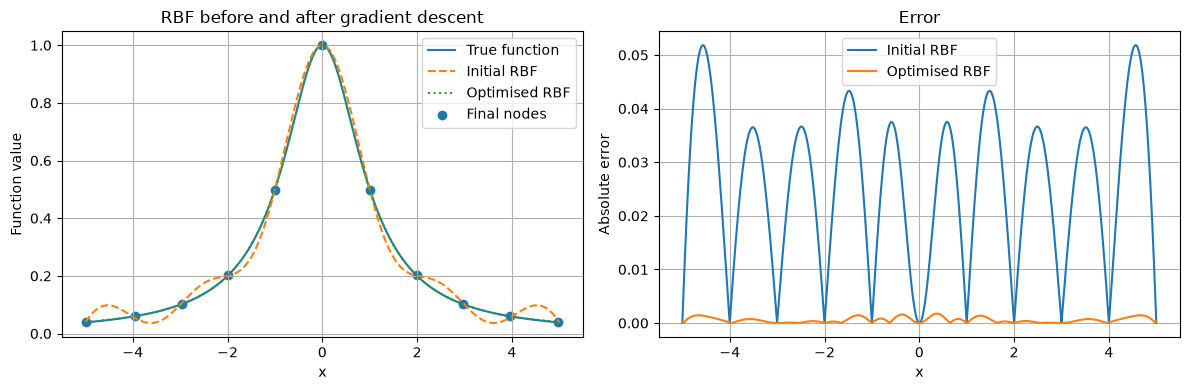

In [ ]:
def test_gradient_decent(f=runge_func, interval=(-5, 5), node_count=11, epsilon=0.5, initial_L=1.0):
    
    a, b = interval
    x = np.linspace(a, b, 1001)
    initial_nodes = rescale(equidistant_nodes(node_count), a, b)
    initial_params = np.concatenate([initial_nodes, [epsilon]])


    initial_cost = cost_func(x, epsilon, f, initial_nodes)

    params, final_cost = gradient_decent(x, f, initial_params.copy(), initial_L, p_hat=0.5, p_sub_hat=2.0)
    final_nodes, final_epsilon = params[:-1], params[-1]

    assert final_cost <= initial_cost + 1e-12, "The final cost is larger than the initial cost" # Meaning you have failed me

    # See whether the result also satisfies the task's constraints
    nodes_inside = np.all((final_nodes >= a) & (final_nodes <= b))
    nodes_distinct = len(np.unique(final_nodes)) == node_count
    print(f"Initial cost: {initial_cost:.6e}")
    print(f"Final cost:   {final_cost:.6e}")
    print(f"Epsilon: {epsilon:.6f} -> {final_epsilon:.6f}")
    print("Final nodes:", final_nodes)
    print("All final nodes within the interval:", nodes_inside)
    print("Final nodes distinct:", nodes_distinct)
    print("Final epsilon positive:", final_epsilon > 0)

    # plotting a comparason
    initial_y = RBF(initial_nodes, f(initial_nodes), x, epsilon)
    final_y = RBF(final_nodes, f(final_nodes), x, final_epsilon)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(x, f(x), label="True function")
    axes[0].plot(x, initial_y, "--", label="Initial RBF")
    axes[0].plot(x, final_y, ":", label="Optimised RBF")
    axes[0].scatter(final_nodes, f(final_nodes), label="Final nodes")
    axes[0].set_ylabel("Function value")
    axes[0].set_title("RBF before and after gradient descent")
    
    axes[1].plot(x, np.abs(f(x) - initial_y), label="Initial RBF")
    axes[1].plot(x, np.abs(f(x) - final_y), label="Optimised RBF")
    axes[1].set_ylabel("Absolute error")
    axes[1].set_title("Error")

    for ax in axes:
        ax.set_xlabel("x")
        ax.legend()
        ax.grid()
    fig.tight_layout()
    plt.show()

    return params, final_cost


gradient_test_params, gradient_test_cost = test_gradient_decent()
